# Analyse semantic-retrieval predictions

Score BGE ranks against expected contact ids for two query sources:
- `hyde_rewrite` expected HyDE text
- `raw_query` original user query (since app's fallback when HyDE is raw user query)

Metrics:
- recall@10 and recall@20
- hit@10 and hit@20

Write `eval/results/semantic_retrieval_results.csv`, then visualise.


## 0. Setup


In [41]:
# %pip install -q pandas matplotlib

In [42]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Navigate up until eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "recall" / "recall_queries.jsonl"
PRED_PATH = REPO_ROOT / "eval" / "predictions" / "semantic_retrieval" / "bge_base_en_v1.5.jsonl"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "semantic_retrieval_results.csv"

KS = (10, 20)
QUERY_SOURCES = ["hyde_rewrite", "raw_query"]

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED:", PRED_PATH.exists(), PRED_PATH)

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/recall/recall_queries.jsonl
PRED: True /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/semantic_retrieval/bge_base_en_v1.5.jsonl


## 1. Load

Read the prediction JSONL, join ground truth on `id`, dump into one DataFrame.


In [43]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows

def expected_contact_ids(expected: dict | None) -> list[int]:
    """
    Pull contact ids from the expected block and keep integers only.
    """
    raw = (expected or {}).get("contact_ids") or []
    ids: list[int] = []
    for item in raw:
        try:
            ids.append(int(item))
        except (TypeError, ValueError):
            continue
    return ids


def ranked_contact_ids(ranked: list | None) -> list[int]:
    """
    Keep predicted contact ids in rank order.
    """
    ids: list[int] = []
    for item in ranked or []:
        # Skip rows that are not objects with a contact_id
        if not isinstance(item, dict):
            continue
        try:
            # Store the id as an int so it can match expected contact ids
            ids.append(int(item["contact_id"]))
        except (KeyError, TypeError, ValueError):
            continue
    return ids


# Load ground truth and index by id
gt_by_id: dict[int, dict] = {}
for row in load_jsonl(GT_PATH):
    gt_by_id[int(row["id"])] = row

# Load predictions and join GT on id
joined_rows: list[dict] = []
for pred in load_jsonl(PRED_PATH):
    query_id = int(pred["id"])
    gt = gt_by_id.get(query_id)
    
    # Skip prediction rows with no matching ground truth
    if gt is None:
        continue
    expected = gt.get("expected") or {}
    expected_ids = expected_contact_ids(expected)
    
    # Skip queries with no expected contacts
    if not expected_ids:
        continue
    ranked = pred.get("ranked") or []
    
    query_source = pred.get("query_source") or "hyde_rewrite"
    joined_rows.append(
        {
            "query_source": query_source,
            "id": query_id,
            "query": gt.get("query", ""),
            "expected_ids": expected_ids,
            "n_expected": len(expected_ids),
            "ranked": ranked,
            "ranked_ids": ranked_contact_ids(ranked),
            "n_ranked": len(ranked),
            "latency_ms": pred.get("latency_ms"),
            "error": pred.get("error"),
        }
    )

raw = pd.DataFrame(joined_rows)
print(raw.shape)
raw.head()

(78, 10)


,query_source,id,query,expected_ids,n_expected,ranked,ranked_ids,n_ranked,latency_ms,error
0,hyde_rewrite,1,who likes hiking,"[1, 48, 50, 87, 107, 132, 140, 143]",8,"[{'contact_id': 1, 'score': 0.6323}, {'contact...","[1, 125, 4, 107, 99, 87, 132, 28, 67, 5, 7, 82...",20,2029.71,None
1,hyde_rewrite,2,who boulders or climbs,"[4, 5, 25, 27, 44, 55, 62, 68, 77, 82, 98, 113...",16,"[{'contact_id': 62, 'score': 0.7096}, {'contac...","[62, 5, 82, 77, 138, 118, 128, 113, 4, 125, 14...",20,54.01,None
2,hyde_rewrite,3,who works in fintech,"[3, 4, 44, 58, 67, 98, 105, 115]",8,"[{'contact_id': 4, 'score': 0.6373}, {'contact...","[4, 44, 58, 2, 80, 67, 98, 56, 1, 105, 115, 3,...",20,43.76,None
3,hyde_rewrite,4,who is a product designer,"[20, 42, 79, 101, 113, 116, 138, 139]",8,"[{'contact_id': 20, 'score': 0.7244}, {'contac...","[20, 138, 79, 116, 42, 123, 101, 131, 74, 88, ...",20,39.12,None
4,hyde_rewrite,5,who did I meet at the career fair,"[1, 2, 55, 56, 67, 76]",6,"[{'contact_id': 98, 'score': 0.7257}, {'contac...","[98, 138, 90, 125, 67, 105, 96, 76, 142, 56, 8...",20,17.74,None


## 2. Score each row

For each query:

- **recall@k** fraction of expected ids in the top k
- **hit@k** 1 if at least one expected id is in the top k


In [44]:
def n_overlap(expected_ids: list[int], ranked_ids: list[int], k: int) -> int:
    """
    Count how many expected ids appear in the first k predicted ids.
    """
    top = set(ranked_ids[:k])
    return sum(1 for contact_id in expected_ids if contact_id in top)


def recall_at_k(expected_ids: list[int], ranked_ids: list[int], k: int) -> float:
    """
    Fraction of expected contacts that appear in the top k.
    """
    return n_overlap(expected_ids, ranked_ids, k) / len(expected_ids)


def hit_at_k(expected_ids: list[int], ranked_ids: list[int], k: int) -> float:
    """
    1 if at least one expected contact is in the top k, else 0.
    """
    return 1.0 if n_overlap(expected_ids, ranked_ids, k) >= 1 else 0.0


def row_has_error(error) -> bool:
    """
    True when the prediction stored a real error string.
    Pandas stores a null error as NaN, which is not an error.
    """
    if error is None:
        return False
    if isinstance(error, float) and math.isnan(error):
        return False
    return True


def score_row(row: pd.Series) -> dict:
    """
    Score one joined prediction row.
    """
    expected_ids = list(row["expected_ids"])
    ranked_ids = list(row["ranked_ids"])
    error = row["error"]
    failed = row_has_error(error)

    scored = {
        "query_source": row["query_source"],
        "id": row["id"],
        "query": row["query"],
        "n_expected": row["n_expected"],
        "n_ranked": row["n_ranked"],
        "latency_ms": row["latency_ms"],
        "error": error,
    }

    # Skip recall and hit when the retrieve step failed
    for k in KS:
        if failed:
            scored[f"recall@{k}"] = None
            scored[f"hit@{k}"] = None
        else:
            scored[f"recall@{k}"] = recall_at_k(expected_ids, ranked_ids, k)
            scored[f"hit@{k}"] = hit_at_k(expected_ids, ranked_ids, k)

    return scored


# Convert per-query scores into DataFrame
scored = pd.DataFrame([score_row(row) for _, row in raw.iterrows()])
print(scored.shape)
scored.head()

(78, 11)


,query_source,id,query,n_expected,n_ranked,latency_ms,error,recall@10,hit@10,recall@20,hit@20
0,hyde_rewrite,1,who likes hiking,8,20,2029.71,None,0.5000,1.0,0.5000,1.0
1,hyde_rewrite,2,who boulders or climbs,16,20,54.01,None,0.5625,1.0,0.8125,1.0
2,hyde_rewrite,3,who works in fintech,8,20,43.76,None,0.7500,1.0,1.0000,1.0
3,hyde_rewrite,4,who is a product designer,8,20,39.12,None,0.7500,1.0,0.8750,1.0
4,hyde_rewrite,5,who did I meet at the career fair,6,20,17.74,None,0.5000,1.0,0.5000,1.0


## 3. Aggregate

- **Recall / hit** = mean over queries, grouped by `query_source`


In [45]:
def mean_metric(frame: pd.DataFrame, column: str) -> tuple[float | None, int]:
    """
    Mean of a metric column, ignoring missing values.
    """
    values = pd.to_numeric(frame[column], errors="coerce").dropna()
    if values.empty:
        return None, 0
    return float(values.mean()), int(len(values))


# Keep rows with no retrieve error
cleaned_rows = scored[~scored["error"].map(row_has_error)].copy()

result_rows: list[dict] = []

# Prefer the fixed query-source order (hyde_rewrite then raw_query)
sources = [s for s in QUERY_SOURCES if s in set(cleaned_rows["query_source"])]
# Fall back to whatever sources are in the file
if not sources:
    sources = sorted(cleaned_rows["query_source"].dropna().unique())

# Macro-average recall and hit for each query source
for source in sources:
    subset = cleaned_rows[cleaned_rows["query_source"] == source]
    # Mean latency across this source's queries
    latency_mean = (
        float(pd.to_numeric(subset["latency_ms"], errors="coerce").mean())
        if not subset.empty
        else None
    )
    for k in KS:
        # Recall@k: fraction of expected ids found in the top k, averaged over queries
        value, n = mean_metric(subset, f"recall@{k}")
        result_rows.append(
            {
                "query_source": source,
                "metric": f"recall@{k}",
                "value": value,
                "n": n,
                "latency_ms_mean": latency_mean,
            }
        )
        # Hit@k: fraction of queries with at least one expected id in the top k
        value, n = mean_metric(subset, f"hit@{k}")
        result_rows.append(
            {
                "query_source": source,
                "metric": f"hit@{k}",
                "value": value,
                "n": n,
                "latency_ms_mean": latency_mean,
            }
        )

# Convert long-format metric rows into a DataFrame
results = pd.DataFrame(result_rows)

# Wide table for a quick look
if results.empty:
    print("No rows without errors. Check the prediction JSONL error field (Postgres may have been down).")
    agg = results
else:
    agg = results.pivot_table(index="query_source", columns="metric", values="value")
    print(cleaned_rows["query_source"].value_counts().to_string())
agg

query_source
hyde_rewrite    39
raw_query       39


metric,hit@10,hit@20,recall@10,recall@20
query_source,,,,
hyde_rewrite,0.974359,1.000000,0.653483,0.788511
raw_query,0.948718,0.974359,0.639102,0.766725


## 4. Save

Overwrite `eval/results/semantic_retrieval_results.csv`.


In [46]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Convert results df to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")
results

Wrote 8 rows to eval/results/semantic_retrieval_results.csv


,query_source,metric,value,n,latency_ms_mean
0,hyde_rewrite,recall@10,0.653483,39,80.038974
1,hyde_rewrite,hit@10,0.974359,39,80.038974
2,hyde_rewrite,recall@20,0.788511,39,80.038974
3,hyde_rewrite,hit@20,1.000000,39,80.038974
4,raw_query,recall@10,0.639102,39,37.600000
5,raw_query,hit@10,0.948718,39,37.600000
6,raw_query,recall@20,0.766725,39,37.600000
7,raw_query,hit@20,0.974359,39,37.600000


## 5. Visualisation

Recall@k and Hit@k bars by query source


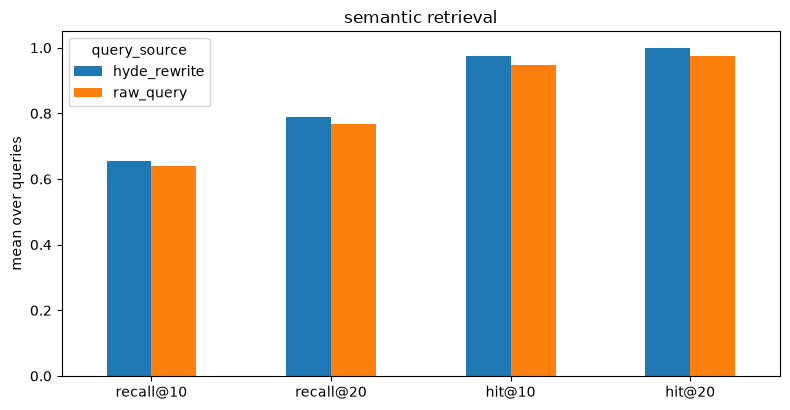

In [47]:
# Grouped bar chart of recall and hit by query source
metric_order = [f"recall@{k}" for k in KS] + [f"hit@{k}" for k in KS]
plot_df = results[results["metric"].isin(metric_order)].copy()
pivot = plot_df.pivot(index="metric", columns="query_source", values="value")
pivot = pivot.reindex(index=metric_order)
cols = [s for s in QUERY_SOURCES if s in pivot.columns]
pivot = pivot[cols]

ax = pivot.plot(kind="bar", figsize=(8, 4.2), rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean over queries")
ax.set_xlabel("")
ax.set_title("semantic retrieval")
ax.legend(title="query_source")
plt.tight_layout()
plt.show()